 0. Setup

In [231]:
import os
import numpy as np
import pandas as pd
import mne

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Softmax, Multiply

1. Initialize

In [232]:
base_path = "ds004395"
subjects = [s for s in os.listdir(base_path) if s.startswith("sub")]

X_all, y_all, subject_ids = [], [], []

bands = {
    "theta": (4, 8),
    "alpha": (8, 12),
    "beta": (13, 30)
}

2. LOOP: Load + Preprocess + Feature Extraction

In [233]:
for sub in subjects:
    sub_path = os.path.join(base_path, sub)
    # Get all sessions inside each subject
    sessions = [ses for ses in os.listdir(sub_path) if ses.startswith("ses")]
    
    for ses in sessions:

        print(f"\n🔍 Processing {sub}-{ses}")

        eeg_file = f"{sub}_{ses}_task-ltpFR_eeg.edf"
        events_file = f"{sub}_{ses}_task-ltpFR_events.tsv"

        eeg_path = os.path.join(base_path, sub, ses, "eeg", eeg_file)
        events_path = os.path.join(base_path, sub, ses, "eeg", events_file)

        # -------- LOAD EEG --------
        raw = mne.io.read_raw_edf(eeg_path, preload=True)
        print("✔ EEG loaded")

        # -------- MONTAGE --------
        montage = mne.channels.make_standard_montage("GSN-HydroCel-129")
        raw.set_montage(montage, on_missing='ignore')
        print("✔ Montage set")

        # -------- FILTER --------
        raw.filter(0.5, 40)
        raw.set_eeg_reference('average')
        print("✔ Filtered")

        # -------- LOAD EVENTS --------
        events = pd.read_csv(events_path, sep="\t")
        print("✔ Events loaded:", len(events))

        # 🔥 DEBUG: CHECK EVENT TYPES
        print("Event types:", events["trial_type"].unique())

        print("Columns:", events.columns)
        print(events.head())
    
        # -------- DETECT CORRECT COLUMNS --------
        if "onset" in events.columns:
            time_col = "onset"
        else:
            raise ValueError("❌ No time column found")
    
        if "trial_type" in events.columns:
            event_col = "trial_type"
        else:
            raise ValueError("❌ No event type column found")
    
        print("Using time column:", time_col)
        print("Using event column:", event_col)
        
        # -------- CLEAN EVENTS --------
        rec_events = events.copy()
        rec_events = rec_events.dropna(subset=[time_col])
        
        print("Filtered events:", len(rec_events))

        def create_label(row):
            if row["trial_type"] == "REC_WORD":
                return 1   # correct recall
            elif row["trial_type"] == "REC_WORD_VV":
                return 0   # intrusion
            else:
                return 2   # ignore
        
        y = rec_events.apply(create_label, axis=1).values
        
        # 🔥 REMOVE UNUSED CLASS
        mask = y != 2
        rec_events = rec_events[mask]
        y = y[mask]
        
        print("After labeling:", np.unique(y, return_counts=True))
        # -------- LABELS (TEMP SIMPLE VERSION) --------
        # You can refine later
        # -------- TIME ALIGNMENT --------
        sfreq = raw.info['sfreq']
        sample = (rec_events[time_col] * sfreq).astype(int)
        
        valid = sample < len(raw.times)
        sample = sample[valid]
        y = y[valid]

        
        print("Valid events:", len(sample))

        print("Valid events:", len(sample))

        # -------- CREATE EVENTS ARRAY --------
        events_array = np.column_stack([
            sample,
            np.zeros(len(sample), dtype=int),
            np.ones(len(sample), dtype=int)
        ])

        # -------- EPOCHING --------
        epochs = mne.Epochs(
            raw,
            events_array,
            event_id={"recall": 1},
            tmin=-1,
            tmax=1,
            baseline=(-0.2, 0),
            preload=True,
            reject=None,
            event_repeated='drop'   # 🔥 ADD THIS
        )

        print("Epochs created:", len(epochs))

        if len(epochs) == 0:
            print("⚠️ Skipping due to 0 epochs")
            continue

        y = y[:len(epochs)]

        # -------- PSD FEATURE EXTRACTION --------
        psds, freqs = mne.time_frequency.psd_array_welch(
            epochs.get_data(),
            sfreq=sfreq,
            fmin=4,
            fmax=30
        )

        features = []
        for band, (fmin, fmax) in bands.items():
            idx = (freqs >= fmin) & (freqs <= fmax)
            band_power = psds[:, :, idx].mean(axis=2)
            features.append(band_power)

        X = np.concatenate(features, axis=1)

        print("✅ Features shape:", X.shape)

        # -------- STORE --------
        X_all.append(X)
        y_all.append(y)
        subject_ids.extend([sub] * len(y))


🔍 Processing sub-LTP063-ses-0
Extracting EDF parameters from ds004395\sub-LTP063\ses-0\eeg\sub-LTP063_ses-0_task-ltpFR_eeg.edf...


C:\Users\vandi\AppData\Local\Temp\ipykernel_10800\2296838837.py:17: RuntimeWarning: Invalid measurement date encountered in the header.
  raw = mne.io.read_raw_edf(eeg_path, preload=True)


ValueError: Bad EDF file provided.

In [227]:
print(type(X_all[0]), X_all[0].shape)

<class 'numpy.ndarray'> (115, 387)


 3. Combine Data

In [228]:
print("Total chunks:", len(X_all))

X_all = np.vstack(X_all)
y_all = np.concatenate(y_all)
subject_ids = np.array(subject_ids)

print("Final shape:", X_all.shape, y_all.shape)
# SAFETY CHECK
assert len(X_all) == len(y_all) == len(subject_ids)

Total chunks: 6
Final shape: (896, 387) (896,)


In [220]:
print(np.unique(y_all, return_counts=True))

(array([0, 1]), array([ 23, 873]))


4. GROUPKFOLD (Subject-wise Validation)


🔥 Fold 1
Predictions: (array([1]), array([390]))
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        19
           1       0.95      1.00      0.98       371

    accuracy                           0.95       390
   macro avg       0.48      0.50      0.49       390
weighted avg       0.90      0.95      0.93       390

ROC-AUC: 0.6859128954461626


C:\Users\vandi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\vandi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\vandi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


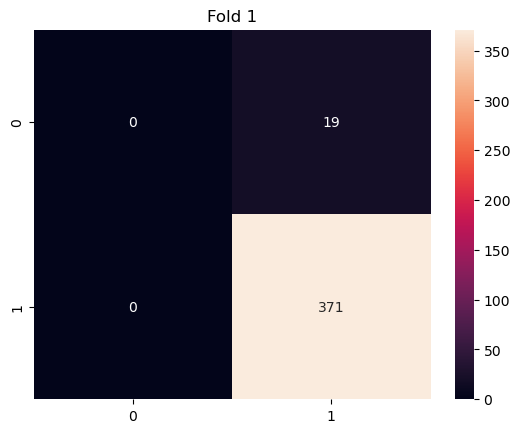


🔥 Fold 2
Predictions: (array([0, 1]), array([  8, 262]))
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.98      0.97      0.98       266

    accuracy                           0.96       270
   macro avg       0.49      0.48      0.49       270
weighted avg       0.97      0.96      0.96       270

ROC-AUC: 0.7152255639097744


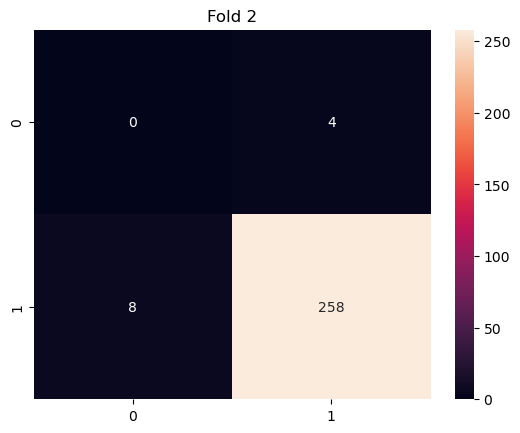


🔥 Fold 3
Predictions: (array([1]), array([236]))
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       236

    accuracy                           1.00       236
   macro avg       1.00      1.00      1.00       236
weighted avg       1.00      1.00      1.00       236

ROC-AUC: nan


C:\Users\vandi\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\vandi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


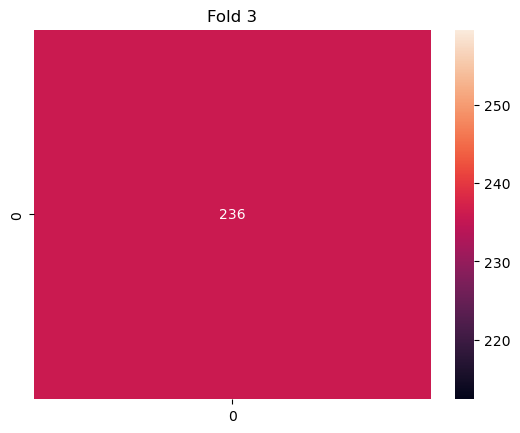

In [229]:
# -------- MODEL TRAINING --------
gkf = GroupKFold(n_splits=3)

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_all, y_all, subject_ids)):

    print(f"\n🔥 Fold {fold+1}")

    X_train, X_test = X_all[train_idx], X_all[test_idx]
    y_train, y_test = y_all[train_idx], y_all[test_idx]

    # NORMALIZATION
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # MODEL
    svm = SVC(kernel="rbf", class_weight="balanced", probability=True)
    svm.fit(X_train, y_train)

    pred = svm.predict(X_test)
    probs = svm.predict_proba(X_test)[:, 1]

    print("Predictions:", np.unique(pred, return_counts=True))

    # METRICS
    print(classification_report(y_test, pred))
    print("ROC-AUC:", roc_auc_score(y_test, probs))

    # CONFUSION MATRIX
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"Fold {fold+1}")
    plt.show()

In [ ]:
5. EXPLAINABILITY

In [230]:
import shap

explainer = shap.Explainer(svm.predict, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

ValueError: max_evals=500 is too low for the Permutation explainer, it must be at least 2 * num_features + 1 = 775!

6. BRAIN VISUALIZATION

In [121]:
importance = np.abs(X_train).mean(axis=0)
importance = importance.reshape(3, -1)

mne.viz.plot_topomap(importance[0], raw.info)
plt.title("Theta Importance")
plt.show()

ValueError: cannot reshape array of size 128128 into shape (3,newaxis)

7. DEEP LEARNING (CNN-LSTM + ATTENTION)

In [ ]:
X_dl = epochs.get_data()
X_dl = np.transpose(X_dl, (0, 2, 1))

X_train, X_test, y_train, y_test = train_test_split(
    X_dl, y_all, test_size=0.2, stratify=y_all
)

# class weights
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict = dict(enumerate(cw))

inputs = Input(shape=(X_train.shape[1], X_train.shape[2]))

x = Conv1D(64, 3, activation='relu')(inputs)
x = MaxPooling1D(2)(x)

x = LSTM(64, return_sequences=True)(x)

attention = Dense(1, activation='tanh')(x)
attention = Softmax(axis=1)(attention)

x = Multiply()([x, attention])

x = LSTM(32)(x)
x = Dense(32, activation='relu')(x)
x = Dropout(0.5)(x)

outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=cw_dict
)

8. ATTENTION HEATMAP

In [ ]:
attention_model = Model(inputs=model.input, outputs=attention)
attn = attention_model.predict(X_test[:1]).squeeze()

plt.plot(attn)
plt.title("Attention Heatmap")
plt.show()

9. SAVE MODEL

In [ ]:
import joblib
joblib.dump(svm, "svm.pkl")
joblib.dump(scaler, "scaler.pkl")

model.save("dl_model.h5")

10. INFERENCE PIPELINE

In [ ]:
# load
svm = joblib.load("svm.pkl")
scaler = joblib.load("scaler.pkl")

# preprocess new EEG → X_new

X_new = scaler.transform(X_new)
pred = svm.predict(X_new)
prob = svm.predict_proba(X_new)